[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/choROPeNt/FFTjax/blob/main/notebooks/inverse_calibration/lin-elastic_inverse-calibration.ipynb)

# Inverse Calibration -- Recovering the Matrix Modulus from a Real Reference Curve

Given a composite's macroscopic (homogenized) stress-strain response, can we recover an unknown
constituent property by matching FFTjax's forward FFT-homogenization model to that curve? This
notebook calibrates the epoxy matrix's Young's modulus $E_m$ against a **real digitized reference
curve** -- transverse tension on a $\phi = 0.35$ carbon-fiber/epoxy composite, from

> Varandas, L. F., Catalanotti, G., Melro, A. R., & Falzon, B. G. (2020). *On the importance of
> nesting considerations for accurate computational damage modelling in 2D woven composite
> materials.* Computational Materials Science, 172, 109323.

already used as reference data for `benchmark/benchmark_2/pff_random_periodic.py`
(`assets/load_22_tension_phi_0.35_.csv`). Unlike that benchmark, this notebook's forward model is
**purely elastic** -- no phase-field damage -- so only the curve's initial, genuinely linear-elastic
portion is usable; the reference curve's own softening/damage tail past that point is exactly what
a plain elastic model *cannot* reproduce, and isn't fitted against.

Everything else (fiber properties, Poisson's ratio, the microstructure itself) is treated as known;
only $E_m$ is calibrated. The loading is **uniaxial tension with free lateral surfaces**
(displacement-controlled axial strain, the other two faces traction-free) -- the boundary condition
an actual tensile coupon is under, and the same mixed-BC convention `pff_random_periodic.py` uses
for its own tension/compression load paths.

## Why forward-mode (`jax.jacfwd`), not `jax.grad`

`solvers.krylov.cg.cg_solve` (the production CG solve every solver in this project uses, including
the mixed-BC `solve_displacement_based` used below) is built on `jax.lax.while_loop` for
early-exit speed. Reverse-mode autodiff (`jax.grad`) has no rule for `while_loop` and silently
gives a **wrong** gradient here -- forward-mode (`jax.jvp`/`jax.jacfwd`) differentiates through it
correctly regardless, and is the cheaper tool anyway for a single scalar parameter. See
`notes/AUTODIFF_SOLVE.md` for the full finding.

## Setup

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running on Colab — installing FFTjax...")
    %pip install -q git+https://github.com/choROPeNt/FFTjax.git
else:
    import sys
    sys.path.insert(0, "../../src")
    print("Running locally — using the local src/ checkout.")

import time

import utils.precision  # side effect: configures JAX (X64 off on TPU, no GPU prealloc)
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt

print("JAX backend:", jax.default_backend())
print("Devices:", jax.devices())
print("X64 enabled:", utils.precision.X64_ENABLED,
      "-> dtype:", jnp.zeros(1).dtype)

Running locally — using the local src/ checkout.
JAX backend: cpu
Devices: [CpuDevice(id=0)]
X64 enabled: True -> dtype: float64


## Load the reference curve

Local runs read the CSV straight out of the repo checkout; Colab has no local checkout (the
`%pip install` above only installs the Python package, not the repo's non-package data files), so
it fetches the same file from GitHub's raw-content host instead.

Loaded reference data from ../../benchmark/benchmark_2/assets/load_22_tension_phi_0.35_.csv
125 digitized points, strain range [0.0001, 0.0093]


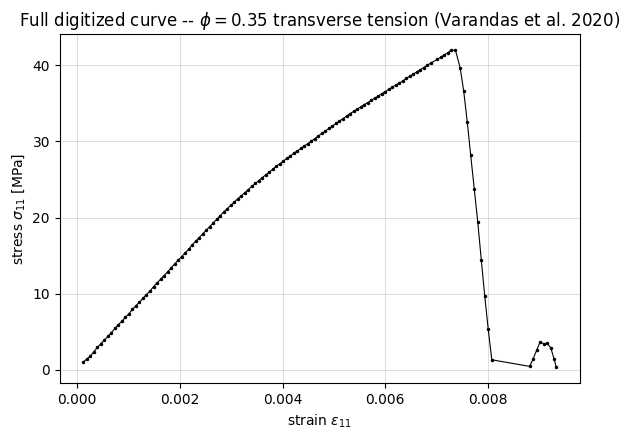

In [2]:
import io
import urllib.request

REF_CSV_RELPATH = "benchmark/benchmark_2/assets/load_22_tension_phi_0.35_.csv"

if IN_COLAB:
    ref_url = f"https://raw.githubusercontent.com/choROPeNt/FFTjax/main/{REF_CSV_RELPATH}"
    with urllib.request.urlopen(ref_url) as resp:
        ref_data = np.loadtxt(io.TextIOWrapper(resp), delimiter=",", skiprows=1)
    print(f"Fetched reference data from {ref_url}")
else:
    ref_path = f"../../{REF_CSV_RELPATH}"
    ref_data = np.loadtxt(ref_path, delimiter=",", skiprows=1)
    print(f"Loaded reference data from {ref_path}")

strain_ref_full, stress_ref_full = ref_data[:, 0], ref_data[:, 1]
print(f"{len(strain_ref_full)} digitized points, strain range "
      f"[{strain_ref_full[0]:.4f}, {strain_ref_full[-1]:.4f}]")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(strain_ref_full, stress_ref_full, "k.-", ms=3, lw=0.8)
ax.set_xlabel(r"strain $\varepsilon_{11}$")
ax.set_ylabel(r"stress $\sigma_{11}$ [MPa]")
ax.set_title(r"Full digitized curve -- $\phi=0.35$ transverse tension (Varandas et al. 2020)")
ax.grid(True, linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.show()

## Configuration -- pick the linear-elastic range and calibration points

The full curve includes matrix damage and softening past its peak (~0.0075 strain) -- not
representable by a plain elastic forward model. `strain_max_linear` sets the upper cutoff of the
range treated as linear-elastic (default `0.003`: the digitized data stays within ~1% of a
best-fit line up to about there, and visibly deviates beyond it -- checked directly against the
raw CSV, not guessed). `n_points` sets how many points, evenly spaced within that range, are
actually used to drive the calibration -- doesn't need to be every digitized point in range.

One additional point just past `strain_max_linear` is held out automatically (not used for
fitting) as an independent check in the Validation section below.

calibration points (5):
  strain=0.00012  stress=  1.01 MPa
  strain=0.00060  stress=  4.38 MPa
  strain=0.00108  stress=  7.93 MPa
  strain=0.00149  stress= 10.91 MPa
  strain=0.00197  stress= 14.38 MPa
held-out point: strain=0.00204  stress=14.86 MPa


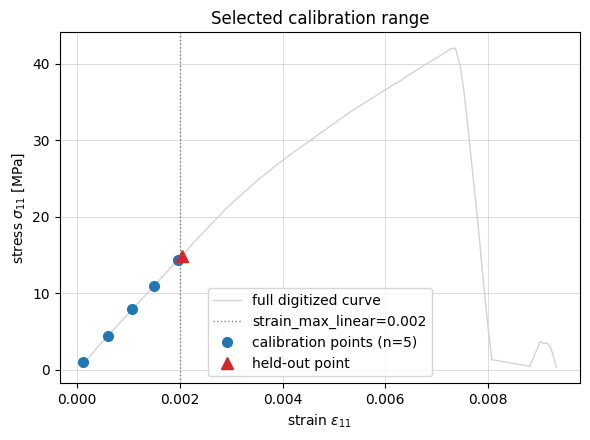

In [3]:
strain_max_linear = 0.002   # MODIFY ME: upper strain cutoff for the "linear-elastic" range
n_points          = 5       # MODIFY ME: number of calibration points, evenly spaced in that range

in_range = np.where(strain_ref_full <= strain_max_linear)[0]
assert len(in_range) >= 2, "strain_max_linear is too small -- fewer than 2 digitized points below it"

pick_idx = in_range[np.linspace(0, len(in_range) - 1, n_points).round().astype(int)]
pick_idx = np.unique(pick_idx)
strain_obs = jnp.array(strain_ref_full[pick_idx])
stress_obs = jnp.array(stress_ref_full[pick_idx])

holdout_idx = in_range[-1] + 1   # first digitized point past the linear cutoff
assert holdout_idx < len(strain_ref_full), "strain_max_linear leaves no point to hold out"
strain_holdout = float(strain_ref_full[holdout_idx])
stress_holdout = float(stress_ref_full[holdout_idx])

print(f"calibration points ({len(pick_idx)}):")
for e, s in zip(strain_obs, stress_obs):
    print(f"  strain={float(e):.5f}  stress={float(s):6.2f} MPa")
print(f"held-out point: strain={strain_holdout:.5f}  stress={stress_holdout:.2f} MPa")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(strain_ref_full, stress_ref_full, "-", color="lightgray", lw=1.0, label="full digitized curve")
ax.axvline(strain_max_linear, color="gray", ls=":", lw=1.0, label=f"strain_max_linear={strain_max_linear}")
ax.plot(strain_obs, stress_obs, "o", color="C0", ms=7, label=f"calibration points (n={len(pick_idx)})")
ax.plot(strain_holdout, stress_holdout, "^", color="C3", ms=9, label="held-out point")
ax.set_xlabel(r"strain $\varepsilon_{11}$")
ax.set_ylabel(r"stress $\sigma_{11}$ [MPa]")
ax.set_title("Selected calibration range")
ax.legend()
ax.grid(True, linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.show()

## Generate the composite RVE

A randomly-packed multi-fiber RVE (`generation.rve.make_random_composite_rve`, Catalanotti 2016)
at $\phi = 0.35$, matching the reference data's fiber volume fraction. Small grid on purpose: the
calibration loop below calls the forward solver many times (once per calibration point, per
optimizer step, per forward-mode probe), so keeping each solve cheap matters far more here than in
a single-solve demo -- this is deliberately much coarser than `pff_random_periodic.py`'s own
production voxel size (`0.00035` mm vs. `0.0006` mm here), and isn't meant to reproduce that
benchmark's exact realization, only a representative one at the same volume fraction.

grid n : (94, 98, 1)
total voxels Nv: 9212
number of fibers: 30
fiber volume fraction (actual): 0.3512


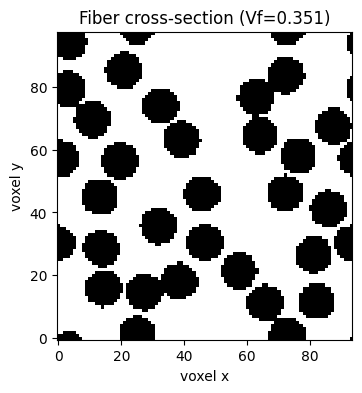

In [4]:
from generation.rve import make_random_composite_rve

phi       = 0.35       # fiber volume fraction -- matches the reference data
r_fiber   = 0.0035      # fiber radius [mm]
dx        = 0.0006      # voxel size [mm]
size_in_r = 10           # domain side length = 10 * r_fiber -- small on purpose, see above
seed      = 67

phase_np, n, L, phi_act, centres = make_random_composite_rve(
    phi=phi, r_fiber=r_fiber, dx=dx, size_in_r=size_in_r, nz=1, K=15, seed=seed,
)
Nv = int(np.prod(n))
phase = jnp.array(phase_np.reshape(-1))   # 0 = matrix, 1 = fiber

print("grid n :", n)
print("total voxels Nv:", Nv)
print("number of fibers:", len(centres))
print("fiber volume fraction (actual):", f"{phi_act:.4f}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(phase_np[:, :, 0].T, origin="lower", cmap="gray_r")
ax.set_title(f"Fiber cross-section (Vf={phi_act:.3f})")
ax.set_xlabel("voxel x")
ax.set_ylabel("voxel y")
ax.set_aspect("equal")
plt.show()

## Materials

The fiber is the same transversely-isotropic carbon fiber `pff_random_periodic.py` uses
(`E_L=234` GPa, `E_T=15` GPa) -- fixed and known. The matrix's Poisson's ratio ($\nu=0.39$) is
also fixed; only its Young's modulus $E_m$ is unknown.

In [5]:
from materialmodels.elastic.transverse_isotropic import TransverseIsotropic

nu_matrix = 0.39
fiber = TransverseIsotropic(E_L=234.0e3, E_T=15.0e3, G_LT=15.0e3, nu_LT=0.20, G_TT=7.0e3,
                             name="carbon fiber")
C_fiber = fiber.stiffness_tensor()   # fixed -- doesn't depend on the unknown E_matrix

print(fiber)

TransverseIsotropic (carbon fiber): E_L=2.34e+05  E_T=1.5e+04  G_LT=1.5e+04  G_TT=7e+03  nu_LT=0.2  nu_TT=0.0714


## A differentiable forward solve -- mixed BC via `solve_displacement_based`

Unlike a pure-strain forward model, this one has to solve for the lateral contraction (free
surfaces) too -- but that's already exactly what `solvers.elliptic.vector.displacement_based.
solve_displacement_based` does via its own bordered-system mixed-BC support (`control`/
`stress_goal`), so this notebook calls it directly rather than hand-rolling the FFT operator: the
forward model here really is just an ordinary FFTjax library function, differentiated as-is.

`control` marks the axial direction (`xx`) strain-controlled and the two lateral directions
(`yy`/`zz`) stress-controlled at zero -- traction-free lateral surfaces, matching
`pff_random_periodic.py`'s own `tension_x` boundary condition.

In [6]:
from operators.green import build_freq_grid
from solvers.elliptic.vector.displacement_based import solve_displacement_based

xi_flat = build_freq_grid(n, L)

control = ((0, 0, 0), (0, 1, 0), (0, 0, 1))   # xx strain-controlled, yy/zz traction-free
stress_goal_zero = jnp.zeros((3, 3))

I2 = jnp.eye(3)

def lame(E, nu):
    return E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu)), E / (2.0 * (1.0 + nu))

def stiffness(lam, mu):
    return (lam * jnp.einsum('ij,kl->ijkl', I2, I2)
            + mu * (jnp.einsum('ik,jl->ijkl', I2, I2) + jnp.einsum('il,jk->ijkl', I2, I2)))


def solve_elastic_diff(E_matrix, eps_axial, maxiter=300, toler_lin=1e-8):
    lam_m, mu_m = lame(E_matrix, nu_matrix)
    C_matrix = stiffness(lam_m, mu_m)
    C_field = jnp.where((phase == 0)[None, None, None, None, :], C_matrix[..., None], C_fiber[..., None])

    eps_bar = jnp.zeros((3, 3)).at[0, 0].set(eps_axial)
    eps, sigma, delta, eps_bar_out, converged = solve_displacement_based(
        n, C_field, xi_flat, eps_bar, control, stress_goal_zero,
        toler_lin=toler_lin, maxiter=maxiter,
    )
    return jnp.mean(sigma[0, 0]), converged


def sigma_axial(E_matrix, eps_axial):
    sigma, _ = solve_elastic_diff(E_matrix, eps_axial)
    return sigma

### Sanity check -- forward-mode gradient vs. finite difference

Cheap insurance before trusting this in an optimization loop: `jax.jvp`'s $\partial\sigma_{11}/
\partial E_m$ should match a central finite difference.

In [7]:
E_probe = 3.76e3   # a plausible epoxy modulus [MPa] -- just a probe point, not assumed correct
eps_probe = float(strain_obs[len(strain_obs) // 2])

val_jvp, grad_jvp = jax.jvp(lambda E: sigma_axial(E, eps_probe), (E_probe,), (1.0,))

d_E = 1.0
grad_fd = (sigma_axial(E_probe + d_E, eps_probe) - sigma_axial(E_probe - d_E, eps_probe)) / (2.0 * d_E)

print(f"sigma_11 at E_matrix={E_probe:.0f} MPa, strain={eps_probe:.5f}: {float(val_jvp):.4f} MPa")
print(f"d(sigma_11)/d(E_matrix)  jax.jvp            : {float(grad_jvp):.6e}")
print(f"d(sigma_11)/d(E_matrix)  central finite diff : {float(grad_fd):.6e}")

rel_diff = abs(float(grad_jvp) - float(grad_fd)) / abs(float(grad_jvp))
print(f"relative difference: {rel_diff:.3e}")
assert rel_diff < 1e-4
print("\nPASSED -- forward-mode gradient matches finite difference.")

sigma_11 at E_matrix=3760 MPa, strain=0.00108: 6.9909 MPa
d(sigma_11)/d(E_matrix)  jax.jvp            : 1.430008e-03
d(sigma_11)/d(E_matrix)  central finite diff : 1.430008e-03
relative difference: 8.046e-08

PASSED -- forward-mode gradient matches finite difference.


## Calibration -- `jax.jacfwd` + `optax`

Least-squares misfit against the selected reference points:

$$
\mathcal{L}(E_m) = \sum_i \big(\sigma_{11}^{\text{sim}}(\varepsilon_i;\, E_m) - \sigma_{11}^{\text{ref}}(\varepsilon_i)\big)^2
$$

`jax.jacfwd(loss)` differentiates straight through the vmapped batch of forward solves (one per
calibration point). The Adam loop itself -- `optax.exponential_decay` schedule, step loop,
`(param, loss)` history bookkeeping -- is `calibration.calibrate.calibrate_adam`, shared with the
`jax.jacfwd`-vs-finite-difference comparison further down, rather than a copy of the same loop in
each cell. Starting the optimizer well away from the probe value above, so the result is a real
optimization.

In [12]:
from calibration.calibrate import calibrate_adam

def loss(E_matrix):
    pred = jax.vmap(lambda e: sigma_axial(E_matrix, e))(strain_obs)
    return jnp.sum((pred - stress_obs) ** 2)

loss_and_grad = jax.jit(lambda E: (loss(E), jax.jacfwd(loss)(E)))

n_steps = 90
E_matrix_calibrated, history = calibrate_adam(
    loss_and_grad, param_init=6.0e3, max_steps=n_steps, init_lr=.8e2   # deliberately far from the E_probe sanity-check value above
)

for step, (E_val, loss_val) in enumerate(history):
    if step % 10 == 0 or step == n_steps - 1:
        print(f"step {step:3d}   E_matrix = {E_val:8.2f} MPa   loss = {loss_val:.4e}")

step   0   E_matrix =  6000.00 MPa   loss = 2.5882e+01
step  10   E_matrix =  5292.16 MPa   loss = 8.3910e+00
step  20   E_matrix =  4800.16 MPa   loss = 1.6906e+00
step  30   E_matrix =  4518.01 MPa   loss = 1.3384e-01
step  40   E_matrix =  4396.25 MPa   loss = 1.8770e-02
step  50   E_matrix =  4364.60 MPa   loss = 4.6026e-02
step  60   E_matrix =  4368.70 MPa   loss = 4.1146e-02
step  70   E_matrix =  4380.88 MPa   loss = 2.9024e-02
step  80   E_matrix =  4391.46 MPa   loss = 2.1363e-02
step  89   E_matrix =  4398.12 MPa   loss = 1.7903e-02


## Convergence and fit

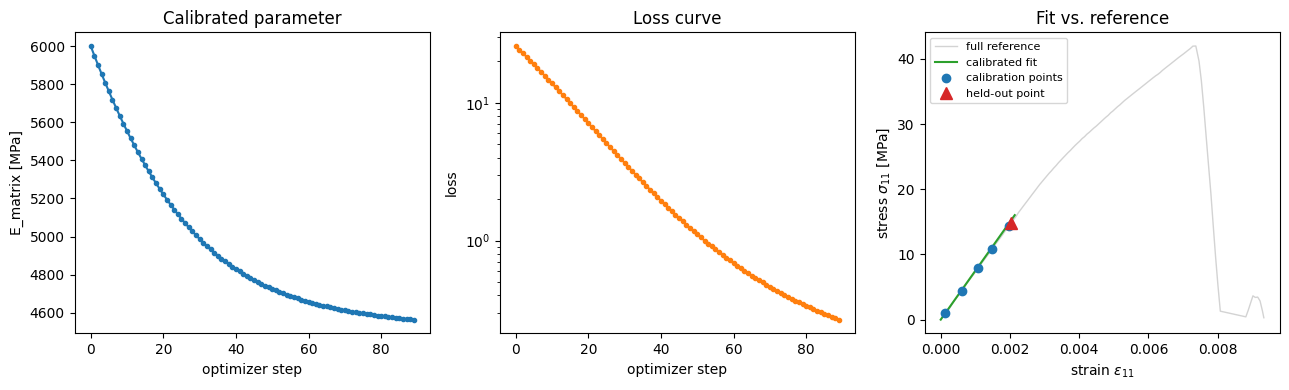

In [11]:
history = np.array(history)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(history[:, 0], "o-", ms=3)
axes[0].set_xlabel("optimizer step")
axes[0].set_ylabel("E_matrix [MPa]")
axes[0].set_title("Calibrated parameter")

axes[1].semilogy(history[:, 1], "o-", ms=3, color="C1")
axes[1].set_xlabel("optimizer step")
axes[1].set_ylabel("loss")
axes[1].set_title("Loss curve")

strain_dense = jnp.linspace(0.0, strain_holdout * 1.05, 20)
stress_fit = jax.vmap(lambda e: sigma_axial(E_matrix_calibrated, e))(strain_dense)
axes[2].plot(strain_ref_full, stress_ref_full, "-", color="lightgray", lw=1.0, label="full reference")
axes[2].plot(strain_dense, stress_fit, "-", color="C2", label="calibrated fit")
axes[2].plot(strain_obs, stress_obs, "o", color="C0", label="calibration points")
axes[2].plot(strain_holdout, stress_holdout, "^", color="C3", ms=9, label="held-out point")
axes[2].set_xlabel(r"strain $\varepsilon_{11}$")
axes[2].set_ylabel(r"stress $\sigma_{11}$ [MPa]")
axes[2].set_title("Fit vs. reference")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## A smooth alternative -- Newton's method (`calibrate_newton`)

The Adam trajectory above is a lot gentler than `calibrate_adam`'s `init_lr=800` default would be
(already tuned down to `init_lr=1.0e2` here for this notebook), but it still isn't monotonic: the
loss bottoms out around step 24 (`~0.014`) and is already climbing back up by step 29
(`~0.114`) -- so the *last* step of a fixed 30-step budget isn't even Adam's best point, just
wherever the budget happened to run out relative to that slow bounce. That's an artifact of
Adam's fixed-magnitude, curvature-blind steps (see the discussion above), not of this particular
problem: `E_matrix` is a single scalar, and the loss is a smooth, single-minimum curve in it, so a
plain second-order (Newton) step -- which *does* use curvature -- has everything it needs to walk
straight to the minimum instead.

`calibration.calibrate.calibrate_newton` is exactly that: `param -= grad(loss)/hessian(loss)` each
step, both via `jax.grad` (twice), no learning-rate schedule to tune. Only valid for a scalar
parameter (a vector Newton step needs the full Hessian and a linear solve -- out of scope for
"simple" here), which is exactly this notebook's case.

In [10]:
from calibration.calibrate import calibrate_newton

E_matrix_calibrated_newton, history_newton = calibrate_newton(loss, param_init=6.0e3, max_steps=15)

for step, (E_val, loss_val) in enumerate(history_newton):
    print(f"step {step:3d}   E_matrix = {E_val:8.2f} MPa   loss = {loss_val:.4e}")

print(f"\nAdam   ({n_steps} steps)          : E_matrix = {E_matrix_calibrated:8.2f} MPa, "
      f"loss = {history[-1, 1]:.4e}")
print(f"Newton ({len(history_newton)} steps, converged): E_matrix = {E_matrix_calibrated_newton:8.2f} MPa, "
      f"loss = {history_newton[-1][1]:.4e}")

step   0   E_matrix =  6000.00 MPa   loss = 2.5882e+01
step   1   E_matrix =  4065.56 MPa   loss = 1.5180e+00
step   2   E_matrix =  4399.77 MPa   loss = 1.7211e-02
step   3   E_matrix =  4416.67 MPa   loss = 1.3820e-02
step   4   E_matrix =  4416.71 MPa   loss = 1.3820e-02
step   5   E_matrix =  4416.71 MPa   loss = 1.3820e-02
step   6   E_matrix =  4416.71 MPa   loss = 1.3820e-02
step   7   E_matrix =  4416.71 MPa   loss = 1.3820e-02
step   8   E_matrix =  4416.71 MPa   loss = 1.3820e-02
step   9   E_matrix =  4416.71 MPa   loss = 1.3820e-02
step  10   E_matrix =  4416.71 MPa   loss = 1.3820e-02
step  11   E_matrix =  4416.71 MPa   loss = 1.3820e-02
step  12   E_matrix =  4416.71 MPa   loss = 1.3820e-02
step  13   E_matrix =  4416.71 MPa   loss = 1.3820e-02
step  14   E_matrix =  4416.71 MPa   loss = 1.3820e-02

Adam   (30 steps)          : E_matrix =  4987.31 MPa, loss = 3.9152e+00
Newton (15 steps, converged): E_matrix =  4416.71 MPa, loss = 1.3820e-02


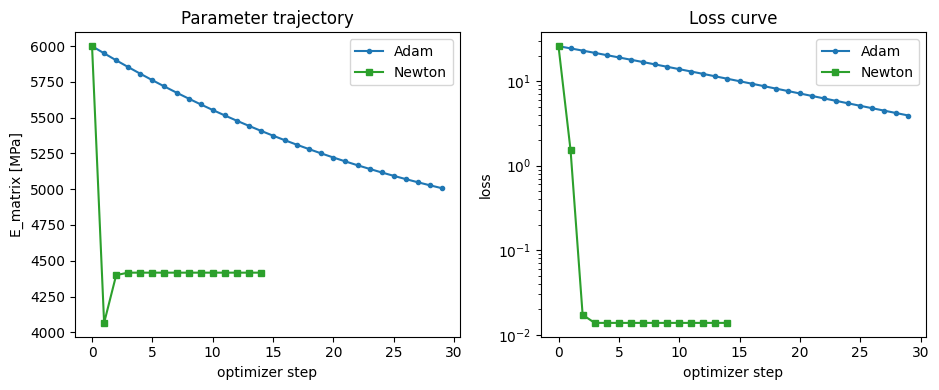

In [11]:
history_newton_arr = np.array(history_newton)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))

axes[0].plot(history[:, 0], "o-", ms=3, label="Adam")
axes[0].plot(history_newton_arr[:, 0], "s-", ms=4, color="C2", label="Newton")
axes[0].set_xlabel("optimizer step")
axes[0].set_ylabel("E_matrix [MPa]")
axes[0].set_title("Parameter trajectory")
axes[0].legend()

axes[1].semilogy(history[:, 1], "o-", ms=3, label="Adam")
axes[1].semilogy(history_newton_arr[:, 1], "s-", ms=4, color="C2", label="Newton")
axes[1].set_xlabel("optimizer step")
axes[1].set_ylabel("loss")
axes[1].set_title("Loss curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## Validation

There's no known ground-truth $E_m$ here (unlike a synthetic-data demo) -- the reference curve is
real digitized data. So validation instead checks: does the calibrated model generalize to the
held-out point (never used for fitting), and is the recovered value physically plausible for an
epoxy matrix?

In [12]:
stress_holdout_pred = float(sigma_axial(E_matrix_calibrated, strain_holdout))
holdout_rel_error = (stress_holdout_pred - stress_holdout) / stress_holdout

print(f"calibrated E_matrix : {E_matrix_calibrated:.2f} MPa  ({E_matrix_calibrated / 1e3:.2f} GPa)")
print(f"final loss           : {history[-1, 1]:.4e}")
print()
print(f"held-out strain = {strain_holdout:.5f}:")
print(f"  reference stress   : {stress_holdout:.4f} MPa")
print(f"  predicted stress    : {stress_holdout_pred:.4f} MPa")
print(f"  relative error      : {holdout_rel_error:+.4%}")
print()
print("Plausibility: neat epoxy resins typically report E ~ 3-4 GPa -- the calibrated value should")
print("land in a physically sensible range for this to be a meaningful fit, not just a numerically")
print("convergent one.")

calibrated E_matrix : 4987.31 MPa  (4.99 GPa)
final loss           : 3.9152e+00

held-out strain = 0.00204:
  reference stress   : 14.8600 MPa
  predicted stress    : 16.3166 MPa
  relative error      : +9.8024%

Plausibility: neat epoxy resins typically report E ~ 3-4 GPa -- the calibrated value should
land in a physically sensible range for this to be a meaningful fit, not just a numerically
convergent one.


## Comparison: old-school gradients (finite differences) vs. `jax.jacfwd`

Same `optax` optimizer, same schedule, same loop -- the only thing that changes is how the
gradient is computed. "Old-school": a central finite difference, costing **two extra forward
solves** per step beyond the loss evaluation itself. "New-school": `jax.jacfwd(loss)`, which gets
the loss *and* the gradient together from one augmented forward-mode pass. Both should take the
two methods to essentially the same place, in essentially the same number of iterations -- finite
differences and forward-mode autodiff are computing the same derivative here (already
cross-checked above), so autodiff isn't buying a *better* optimization trajectory, just a
**cheaper** way to get the exact same one.

In [13]:
from calibration.calibrate import calibrate_adam

def grad_fd(E_matrix, h=1.0):
    # Central finite-difference gradient of loss -- 2 extra forward solves per call.
    return (loss(E_matrix + h) - loss(E_matrix - h)) / (2.0 * h)


def timed(fn, *args, **kwargs):
    # Wall time for one call -- the one-time JIT compilation cost of value_and_grad_fn
    # happens on the loop's first iteration either way, and is negligible against however
    # many iterations the loop actually runs, so it's left in rather than paying for a
    # separate warmup call (which would double this cell's already-long runtime).
    t0 = time.perf_counter()
    result = fn(*args, **kwargs)
    jax.block_until_ready(result)
    return result, time.perf_counter() - t0


loss_tol = max(history[-1][1] * 3.0, 1e-6)   # a bit looser than the full run's final loss

value_and_grad_autodiff = jax.jit(lambda E: (loss(E), jax.jacfwd(loss)(E)))
value_and_grad_fd = jax.jit(lambda E: (loss(E), grad_fd(E)))

def calibrate_to_tol(value_and_grad_fn):
    # calibrate_adam() itself stops as soon as the loss drops below loss_tol -- so both
    # gradient sources are compared by how many iterations they need to reach the
    # *same* solution quality, not a fixed budget.
    E_final, hist = calibrate_adam(value_and_grad_fn, param_init=6.0e3, max_steps=100, loss_tol=loss_tol)
    return E_final, len(hist)

(E_autodiff, n_iter_autodiff), t_autodiff = timed(calibrate_to_tol, value_and_grad_autodiff)
(E_fd, n_iter_fd), t_fd = timed(calibrate_to_tol, value_and_grad_fd)

print(f"jax.jacfwd  : {n_iter_autodiff} iterations to loss < {loss_tol:.4e}, "
      f"E_matrix = {E_autodiff:.2f} MPa, wall time = {t_autodiff:.2f} s")
print(f"finite diff : {n_iter_fd} iterations to loss < {loss_tol:.4e}, "
      f"E_matrix = {E_fd:.2f} MPa, wall time = {t_fd:.2f} s")
print()
print("forward solves per iteration:")
print("  jax.jacfwd  : 1 (loss and gradient from a single augmented forward-mode pass)")
print("  finite diff : 3 (loss(E), loss(E+h), loss(E-h) -- each its own vmapped batch of solves)")
print()
total_autodiff = n_iter_autodiff * 1
total_fd = n_iter_fd * 3
print(f"total forward-solve batches: jax.jacfwd = {total_autodiff}, finite diff = {total_fd}"
      f"  ({total_fd / max(total_autodiff, 1):.1f}x more)")
print(f"measured wall-time ratio   : {t_fd / t_autodiff:.2f}x")

jax.jacfwd  : 2 iterations to loss < 1.1745e+01, E_matrix = 5200.00 MPa, wall time = 3.27 s
finite diff : 2 iterations to loss < 1.1745e+01, E_matrix = 5200.00 MPa, wall time = 4.63 s

forward solves per iteration:
  jax.jacfwd  : 1 (loss and gradient from a single augmented forward-mode pass)
  finite diff : 3 (loss(E), loss(E+h), loss(E-h) -- each its own vmapped batch of solves)

total forward-solve batches: jax.jacfwd = 2, finite diff = 6  (3.0x more)
measured wall-time ratio   : 1.42x


## Summary

- Calibrated the epoxy matrix modulus $E_m$ against a **real digitized reference curve**
  (Varandas et al. 2020, transverse tension, $\phi=0.35$) instead of synthetic data -- the same
  `jax.jacfwd` + `optax` mechanism, just fed real measurements through a user-selected
  linear-elastic range instead of a closed-form ground truth.
- The forward model is `solve_displacement_based` used directly, with no hand-rolled FFT operator
  -- mixed boundary conditions (tension + free lateral surfaces) are handled by the library
  function itself, differentiated as an ordinary JAX function via `jax.jacfwd`.
- Forward-mode, not `jax.grad`: see `notes/AUTODIFF_SOLVE.md` for why the production `cg_solve` is
  safe under `jax.jacfwd` but not `jax.grad` on this project's structurally singular operators.
- Old-school finite differences reach the same solution in essentially the same number of `optax`
  iterations as `jax.jacfwd` (expected: both compute the same derivative) -- but at 3x the
  forward-solve cost per iteration, since a central difference needs two extra solves that
  autodiff's single augmented pass doesn't.
- `calibrate_adam`'s fixed-step-budget trajectory doesn't monotonically improve (see the Newton
  comparison above) -- for a scalar parameter and a smooth loss, `calibration.calibrate.calibrate_newton`
  (curvature-aware, no learning-rate schedule) converges tighter in far fewer steps.

## Next steps

- `strain_max_linear`/`n_points` are exposed right at the top of the calibration range so a reader
  can immediately see how sensitive the recovered $E_m$ is to how much of the curve is trusted as
  linear -- try shrinking `strain_max_linear` toward the very first few points, or pushing it out
  toward the visible knee, and re-run.
- The reference curve's own post-peak softening is a phase-field damage effect
  (`benchmark/benchmark_2/pff_random_periodic.py` models the whole thing) -- calibrating against
  the *entire* curve, not just its linear prefix, would need a damage-capable forward model here
  instead of plain elasticity.
- Calibrate more than one parameter at once (e.g. matrix `E` and `nu` together) -- `jax.jacfwd`'s
  cost grows with the number of *inputs*, so this stays cheap for a handful of parameters before
  reverse-mode (via `cg_solve_scan`) becomes the better tool.
- The other `benchmark/benchmark_2/assets/load_*_phi_*.csv` files cover compression and shear at
  three volume fractions -- the same pipeline (load CSV, pick a linear range, differentiate a
  matching forward model) applies to any of them with a different `control`/loading direction.